<a href="https://colab.research.google.com/github/Nirupamaistack/Digital-Communication/blob/main/Pulse%20Shaping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

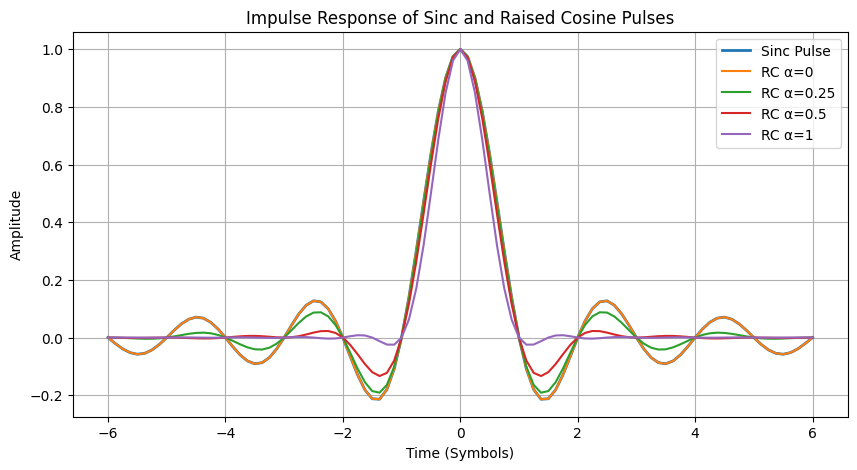

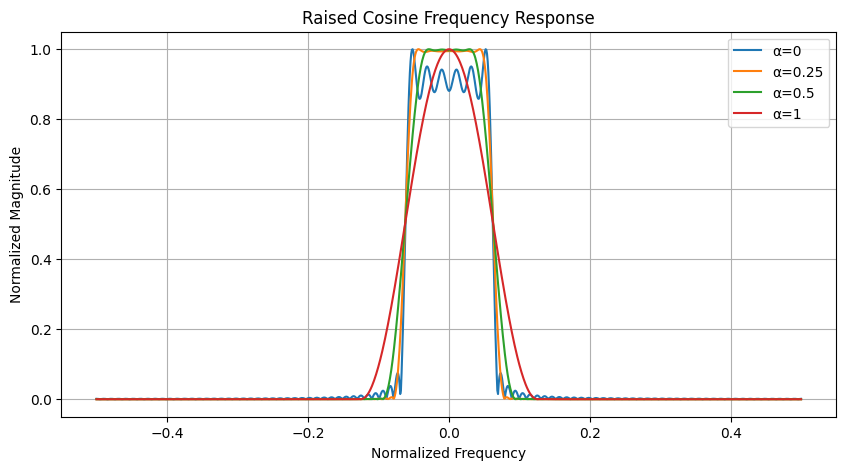

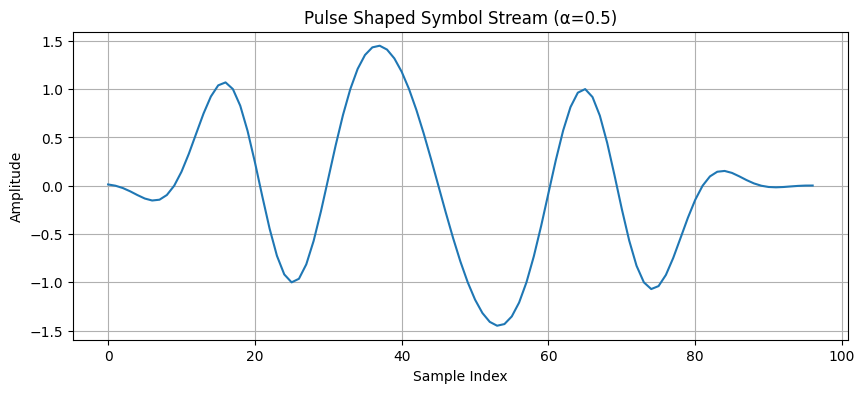

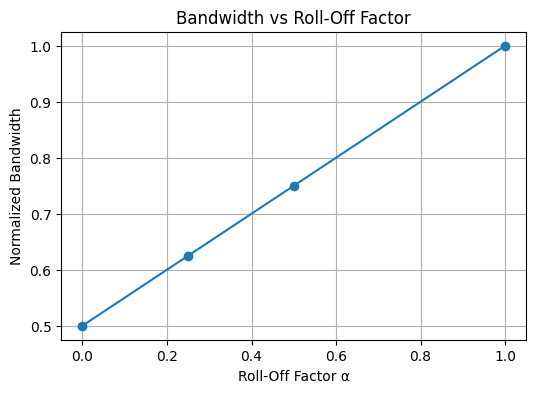

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
sps = 8          # Samples per symbol
span = 6         # Filter span in symbols
alpha_values = [0, 0.25, 0.5, 1]

# -----------------------------
# Sinc Pulse
# -----------------------------
t = np.arange(-span*sps, span*sps+1) / sps
sinc_pulse = np.sinc(t)

# -----------------------------
# Raised Cosine Function
# -----------------------------
def raised_cosine(alpha, span, sps):
    t = np.arange(-span*sps, span*sps+1) / sps
    h = np.zeros_like(t)

    for i, ti in enumerate(t):
        if abs(ti) < 1e-8:
            h[i] = 1
        elif alpha != 0 and abs(abs(2*alpha*ti)-1) < 1e-8:
            h[i] = (np.pi/4)*np.sinc(1/(2*alpha))
        else:
            numerator = np.sinc(ti) * np.cos(np.pi*alpha*ti)
            denominator = 1 - (2*alpha*ti)**2
            h[i] = numerator/denominator

    return t, h

# -----------------------------
# Impulse Responses
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(t, sinc_pulse, label="Sinc Pulse", linewidth=2)

for alpha in alpha_values:
    tt, rc = raised_cosine(alpha, span, sps)
    plt.plot(tt, rc, label=f"RC α={alpha}")

plt.title("Impulse Response of Sinc and Raised Cosine Pulses")
plt.xlabel("Time (Symbols)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Frequency Responses
# -----------------------------
plt.figure(figsize=(10,5))

for alpha in alpha_values:
    tt, rc = raised_cosine(alpha, span, sps)
    H = np.abs(np.fft.fftshift(np.fft.fft(rc,1024)))
    f = np.linspace(-0.5,0.5,len(H))
    plt.plot(f,H/np.max(H),label=f"α={alpha}")

plt.title("Raised Cosine Frequency Response")
plt.xlabel("Normalized Frequency")
plt.ylabel("Normalized Magnitude")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Pulse Shaped Signal
# -----------------------------
bits = np.array([1,-1,1,1,-1,-1,1,-1])
upsampled = np.zeros(len(bits)*sps)
upsampled[::sps] = bits

tt, rc = raised_cosine(0.5, span, sps)
pulse_shaped = np.convolve(upsampled, rc, mode="same")

plt.figure(figsize=(10,4))
plt.plot(pulse_shaped)
plt.title("Pulse Shaped Symbol Stream (α=0.5)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# -----------------------------
# Bandwidth vs Roll-off
# -----------------------------
bandwidth = [(1+a)/2 for a in alpha_values]

plt.figure(figsize=(6,4))
plt.plot(alpha_values, bandwidth, marker='o')
plt.title("Bandwidth vs Roll-Off Factor")
plt.xlabel("Roll-Off Factor α")
plt.ylabel("Normalized Bandwidth")
plt.grid(True)
plt.show()